# 02 - EDA 
**Objetivo:** usar gráficos para descubrir qué características distinguen a un fumador de un no fumador.



In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargo los datos etiquetados
train = pd.read_excel("../data/raw/smoking_train_labeled.xlsx")

print("Datos cargados:", train.shape)


Datos cargados: (50000, 27)


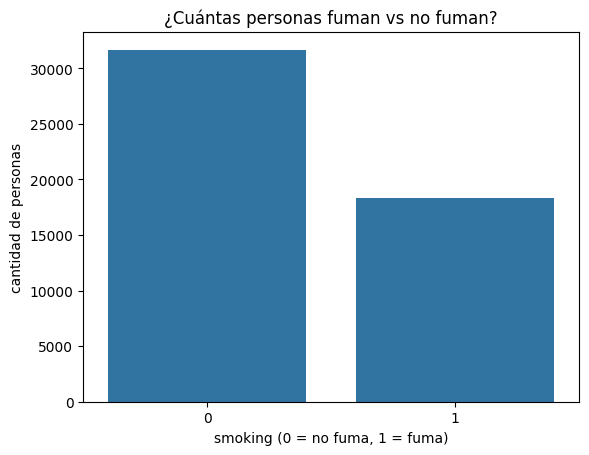

In [2]:
#ver en graficos cuantos fuman y cuantos no,
sns.countplot(data=train, x="smoking")
plt.title("¿Cuántas personas fuman vs no fuman?")
plt.xlabel("smoking (0 = no fuma, 1 = fuma)")
plt.ylabel("cantidad de personas")
plt.show()

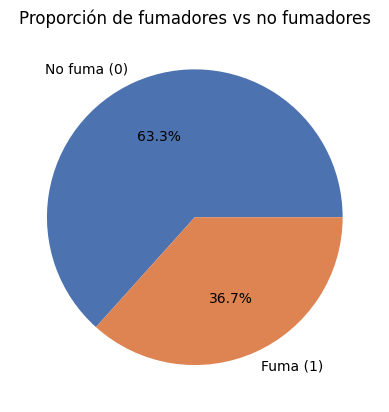

In [3]:
# Gráfico de torta: proporción de fumadores vs no fumadores
train["smoking"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",                      # muestra el % en cada porción
    labels=["No fuma (0)", "Fuma (1)"],
    colors=["#4C72B0", "#DD8452"]
)
plt.title("Proporción de fumadores vs no fumadores")
plt.ylabel("")   # saca un texto feo que pandas pone por defecto
plt.show()


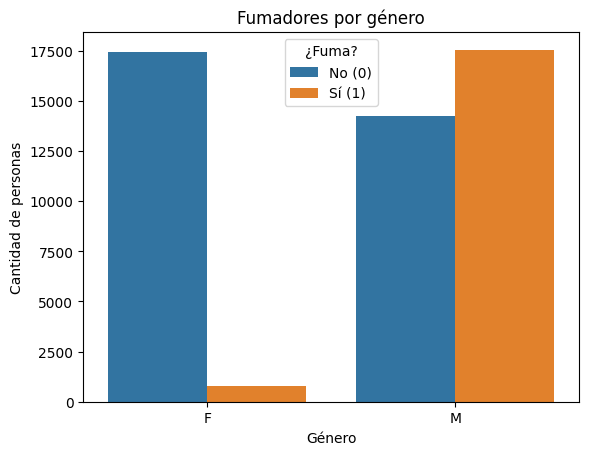

In [4]:
# Fumadores y no fumadores, separados por hombre y mujer
sns.countplot(data=train, x="gender", hue="smoking")
plt.title("Fumadores por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de personas")
plt.legend(title="¿Fuma?", labels=["No (0)", "Sí (1)"])
plt.show()


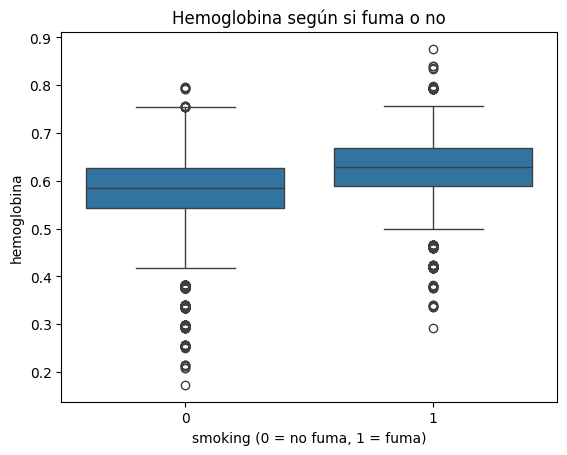

In [5]:
# Boxplot: comparo la hemoglobina entre no fumadores (0) y fumadores (1)
sns.boxplot(data=train, x="smoking", y="hemoglobin")
plt.title("Hemoglobina según si fuma o no")
plt.xlabel("smoking (0 = no fuma, 1 = fuma)")
plt.ylabel("hemoglobina")
plt.show()


In [2]:
import pandas as pd
...
train = pd.read_excel("../data/raw/smoking_train_labeled.xlsx")
# Promedio de cada variable según si la persona fuma o no
train.groupby("smoking").mean(numeric_only=True).round(2)



,ID,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries
smoking,,,,,,,,,,,,,,,,,,,,,
0,26136.23,45.70,161.88,62.94,3.35,0.03,0.03,0.04,0.04,5.03,...,4.71,2.47,4.85,0.57,0.05,0.02,1.06,1.03,1.29,0.18
1,26542.05,41.59,169.45,70.96,3.53,0.03,0.03,0.04,0.04,5.12,...,6.26,2.24,4.69,0.63,0.05,0.02,1.16,1.29,2.32,0.27


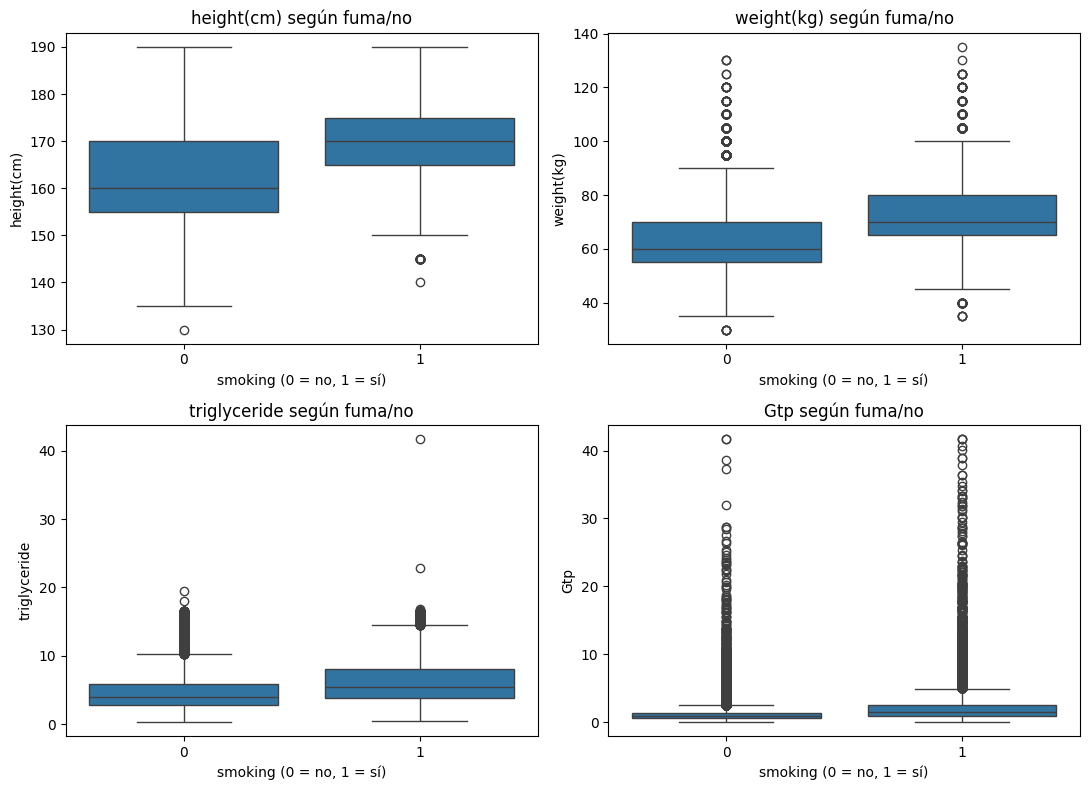

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4 boxplots juntos: cómo varían las variables clave entre fumadores y no
variables = ["height(cm)", "weight(kg)", "triglyceride", "Gtp"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, var in zip(axes.flat, variables):
    sns.boxplot(data=train, x="smoking", y=var, ax=ax)
    ax.set_title(f"{var} según fuma/no")
    ax.set_xlabel("smoking (0 = no, 1 = sí)")
plt.tight_layout()
plt.show()



In [5]:
# % de fumadores dentro de cada grupo (sarro y caries)
print("TARTAR (sarro):")
print((pd.crosstab(train["tartar"], train["smoking"], normalize="index") * 100).round(1))

print("\nDENTAL CARIES (caries):")
print((pd.crosstab(train["dental caries"], train["smoking"], normalize="index") * 100).round(1))


TARTAR (sarro):
smoking     0     1
tartar             
N        68.7  31.3
Y        59.0  41.0

DENTAL CARIES (caries):
smoking           0     1
dental caries            
0              65.9  34.1
1              53.7  46.3


## Conclusiones del EDA

- El target está **desbalanceado** (~63% no fuma, ~37% fuma) → se evalúa con F1, no con accuracy.
- **`gender`** es el predictor más fuerte: ~52% de los hombres fuma vs ~6% de las mujeres.
- **Perfil del fumador** (promedios y boxplots): mayor altura, peso, hemoglobina, triglicéridos y Gtp; menor HDL; y algo más jóvenes.
- Variables **sin diferencia** (no aportan): visión (`eyesight`) y audición (`hearing`).
- **Salud dental**: quienes tienen sarro (41% vs 31%) o caries (46% vs 34%) fuman más → fumar se asocia a peor salud bucal.
- Todo esto **coincide con la importancia de variables del modelo**, lo que da confianza en el análisis.

